# Assignment 2: Sanskrit-to-English Neural Machine Translation
Training notebook. Upload the six dataset CSV files to /content/ before running.

In [1]:
!pip install -q sentencepiece nltk bert-score "transformers==4.46.3"

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import math, time, random
import sentencepiece as spm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 132.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 117.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
cuda


In [2]:
DATA = "/content/"

train_sa = pd.read_csv(DATA + "train_sa_10000.csv")
train_en = pd.read_csv(DATA + "train_en_10000.csv")
dev_sa = pd.read_csv(DATA + "dev_sa_1000.csv")
dev_en = pd.read_csv(DATA + "dev_en_1000.csv")
test_sa = pd.read_csv(DATA + "test_sa_1000.csv")
test_en = pd.read_csv(DATA + "test_en_1000.csv")

train_df = train_sa.merge(train_en, on="Source_id").dropna().reset_index(drop=True)
dev_df = dev_sa.merge(dev_en, on="Source_id").dropna().reset_index(drop=True)
test_df = test_sa.merge(test_en, on="Source_id").dropna().reset_index(drop=True)

print(len(train_df), len(dev_df), len(test_df))
train_df.head()

10000 1000 1000


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [3]:
# joint BPE vocabulary over both languages, trained only on the training split
with open("spm_corpus.txt", "w", encoding="utf-8") as f:
    for s in train_df["Sentence_sa"]:
        f.write(str(s).strip() + "\n")
    for s in train_df["Sentence_en"]:
        f.write(str(s).strip() + "\n")

spm.SentencePieceTrainer.train(
    input="spm_corpus.txt",
    model_prefix="spm_joint",
    vocab_size=8000,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)

sp = spm.SentencePieceProcessor(model_file="spm_joint.model")
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
print(sp.get_piece_size())
print(sp.encode(train_df["Sentence_sa"][1], out_type=str))

8000
['▁ग', 'ुर', 'ुः', '▁छात्र', 'ान्', '▁एकवारं', '▁पाठ', 'यति', '▁।']


In [4]:
MAX_LEN = 64

def encode_pairs(df):
    data = []
    for src, tgt in zip(df["Sentence_sa"], df["Sentence_en"]):
        s = sp.encode(str(src).strip())[:MAX_LEN - 1] + [EOS_ID]
        t = [BOS_ID] + sp.encode(str(tgt).strip())[:MAX_LEN - 2] + [EOS_ID]
        data.append((s, t))
    return data

train_data = encode_pairs(train_df)
dev_data = encode_pairs(dev_df)

In [5]:
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def collate(batch):
    src_max = max(len(s) for s, _ in batch)
    tgt_max = max(len(t) for _, t in batch)
    src = torch.full((len(batch), src_max), PAD_ID, dtype=torch.long)
    tgt = torch.full((len(batch), tgt_max), PAD_ID, dtype=torch.long)
    for i, (s, t) in enumerate(batch):
        src[i, :len(s)] = torch.tensor(s)
        tgt[i, :len(t)] = torch.tensor(t)
    return src, tgt

train_loader = DataLoader(TranslationDataset(train_data), batch_size=64,
                          shuffle=True, collate_fn=collate)
dev_loader = DataLoader(TranslationDataset(dev_data), batch_size=64,
                        shuffle=False, collate_fn=collate)

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=4,
                 dim_ff=1024, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=dim_ff, dropout=dropout, batch_first=True,
        )
        self.out = nn.Linear(d_model, vocab_size)
        self.out.weight = self.embed.weight  # weight tying

    def forward(self, src, tgt_in):
        src_pad = src == PAD_ID
        tgt_pad = tgt_in == PAD_ID
        causal = nn.Transformer.generate_square_subsequent_mask(tgt_in.size(1)).to(src.device)
        src_emb = self.pos_enc(self.embed(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_enc(self.embed(tgt_in) * math.sqrt(self.d_model))
        h = self.transformer(src_emb, tgt_emb, tgt_mask=causal,
                             src_key_padding_mask=src_pad,
                             tgt_key_padding_mask=tgt_pad,
                             memory_key_padding_mask=src_pad)
        return self.out(h)

model = Seq2SeqTransformer(sp.get_piece_size()).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

Parameters: 9,429,824


In [7]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

EPOCHS = 30
steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=5e-4, total_steps=EPOCHS * steps_per_epoch, pct_start=0.1
)

def run_epoch(loader, train_mode=True):
    model.train() if train_mode else model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.set_grad_enabled(train_mode):
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
            n_tok = (tgt_out != PAD_ID).sum().item()
            total_loss += loss.item() * n_tok
            total_tokens += n_tok
    return total_loss / total_tokens

In [8]:
history = {"train": [], "dev": []}
best_dev = float("inf")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss = run_epoch(train_loader, True)
    dv_loss = run_epoch(dev_loader, False)
    history["train"].append(tr_loss)
    history["dev"].append(dv_loss)
    if dv_loss < best_dev:
        best_dev = dv_loss
        torch.save(model.state_dict(), "best_model.pt")
        marker = " *"
    else:
        marker = ""
    print(f"epoch {epoch:02d}  train {tr_loss:.4f}  dev {dv_loss:.4f}  "
          f"({time.time()-t0:.0f}s){marker}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


epoch 01  train 34.4255  dev 22.5518  (16s) *
epoch 02  train 20.7857  dev 15.3942  (16s) *
epoch 03  train 14.0172  dev 10.3780  (16s) *
epoch 04  train 10.0171  dev 8.1669  (16s) *
epoch 05  train 8.2584  dev 7.0697  (16s) *
epoch 06  train 7.4533  dev 6.7653  (17s) *
epoch 07  train 6.9974  dev 6.4961  (17s) *
epoch 08  train 6.6808  dev 6.3305  (17s) *
epoch 09  train 6.4303  dev 6.2410  (16s) *
epoch 10  train 6.2209  dev 6.1247  (16s) *
epoch 11  train 6.0244  dev 6.0182  (17s) *
epoch 12  train 5.8373  dev 5.9531  (17s) *
epoch 13  train 5.6530  dev 5.8829  (17s) *
epoch 14  train 5.4860  dev 5.7697  (17s) *
epoch 15  train 5.3257  dev 5.7252  (17s) *
epoch 16  train 5.1793  dev 5.7094  (16s) *
epoch 17  train 5.0429  dev 5.6864  (16s) *
epoch 18  train 4.9225  dev 5.6572  (17s) *
epoch 19  train 4.8091  dev 5.6719  (16s)
epoch 20  train 4.7082  dev 5.6610  (16s)
epoch 21  train 4.6133  dev 5.6737  (16s)
epoch 22  train 4.5337  dev 5.6984  (17s)
epoch 23  train 4.4668  dev 5.686

## Evaluation on dev set

In [9]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

Seq2SeqTransformer(
  (embed): Embedding(8000, 256, padding_idx=0)
  (pos_enc): PositionalEncoding()
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDecoder(
      (layers): ModuleList(

In [10]:
@torch.no_grad()
def translate_batch(sentences, beam_size=4, max_len=MAX_LEN, alpha=0.6):
    results = []
    for sent in sentences:
        src = sp.encode(str(sent).strip())[:max_len - 1] + [EOS_ID]
        src = torch.tensor(src, device=device).unsqueeze(0)
        src_pad = src == PAD_ID
        memory = model.transformer.encoder(
            model.pos_enc(model.embed(src) * math.sqrt(model.d_model)),
            src_key_padding_mask=src_pad,
        )
        beams = [([BOS_ID], 0.0)]
        finished = []
        for _ in range(max_len):
            candidates = []
            for seq, score in beams:
                if seq[-1] == EOS_ID:
                    finished.append((seq, score))
                    continue
                tgt = torch.tensor(seq, device=device).unsqueeze(0)
                causal = nn.Transformer.generate_square_subsequent_mask(len(seq)).to(device)
                h = model.transformer.decoder(
                    model.pos_enc(model.embed(tgt) * math.sqrt(model.d_model)),
                    memory, tgt_mask=causal, memory_key_padding_mask=src_pad,
                )
                logp = torch.log_softmax(model.out(h[0, -1]), dim=-1)
                topv, topi = logp.topk(beam_size)
                for v, i in zip(topv.tolist(), topi.tolist()):
                    candidates.append((seq + [i], score + v))
            if not candidates:
                break
            beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_size]
        finished.extend(beams)
        # length-normalised scoring
        best = max(finished, key=lambda x: x[1] / (len(x[0]) ** alpha))
        toks = [t for t in best[0] if t not in (BOS_ID, EOS_ID, PAD_ID)]
        results.append(sp.decode(toks))
    return results

In [11]:
import nltk
from nltk.translate.bleu_score import corpus_bleu

# quick check on a few dev sentences
sample = dev_df.head(5)
preds = translate_batch(sample["Sentence_sa"].tolist())
for s, r, p in zip(sample["Sentence_sa"], sample["Sentence_en"], preds):
    print("SA :", s)
    print("REF:", r)
    print("HYP:", p)
    print()

SA : ते वीराः ।
REF: Those are brave men.
HYP: Let's go backwards.

SA : 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
REF: Infinite loop  can cause the system to become unresponsive.
HYP: In this tutorial, we will learn to create a user.

SA : ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
REF: "And they spit upon him, and took the reed, and smote him on the head."
HYP: "And he said unto them, The Son of God."

SA : एते तिथी ।
REF: These two are dates.
HYP: These two areny.

SA : "बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् सुसंवादं श्रुत्वा विश्वसन्ति तदर्थं बहुदिनात् पूर्व्वम् ईश्वरोस्माकं मध्ये मां वृत्वा नियुक्तवान्।"
REF: "And when there had been much disputing, Peter rose up, and said unto them, Men and brethren, ye know how that a good while ago God made choice among us, that the Gentiles by my mouth should hear the word of the gospel, and believe."
HYP: "And when he had said unto them, and said unto them, and said unto them,

In [13]:
t0 = time.time()
dev_preds = translate_batch(dev_df["Sentence_sa"].tolist())
print(f"decode time: {time.time()-t0:.1f}s")

refs = [[str(r).split()] for r in dev_df["Sentence_en"]]
hyps = [p.split() for p in dev_preds]
print("Dev BLEU:", corpus_bleu(refs, hyps))

decode time: 942.1s
Dev BLEU: 0.03623882471804753


In [14]:
@torch.no_grad()
def translate_greedy(sentences, batch_size=64, max_len=MAX_LEN):
    results = []
    for i in range(0, len(sentences), batch_size):
        chunk = [str(s).strip() for s in sentences[i:i + batch_size]]
        enc = [sp.encode(s)[:max_len - 1] + [EOS_ID] for s in chunk]
        src_max = max(len(e) for e in enc)
        src = torch.full((len(enc), src_max), PAD_ID, dtype=torch.long, device=device)
        for j, e in enumerate(enc):
            src[j, :len(e)] = torch.tensor(e, device=device)
        src_pad = src == PAD_ID
        memory = model.transformer.encoder(
            model.pos_enc(model.embed(src) * math.sqrt(model.d_model)),
            src_key_padding_mask=src_pad,
        )
        tgt = torch.full((len(enc), 1), BOS_ID, dtype=torch.long, device=device)
        done = torch.zeros(len(enc), dtype=torch.bool, device=device)
        for _ in range(max_len):
            causal = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(device)
            h = model.transformer.decoder(
                model.pos_enc(model.embed(tgt) * math.sqrt(model.d_model)),
                memory, tgt_mask=causal, memory_key_padding_mask=src_pad,
            )
            nxt = model.out(h[:, -1]).argmax(-1, keepdim=True)
            nxt[done] = PAD_ID
            tgt = torch.cat([tgt, nxt], dim=1)
            done |= nxt.squeeze(1) == EOS_ID
            if done.all():
                break
        for row in tgt.tolist():
            toks = [t for t in row if t not in (BOS_ID, EOS_ID, PAD_ID)]
            results.append(sp.decode(toks))
    return results

In [15]:
t0 = time.time()
dev_greedy = translate_greedy(dev_df["Sentence_sa"].tolist())
greedy_time = time.time() - t0
print(f"greedy decode time: {greedy_time:.1f}s")

hyps = [p.split() for p in dev_greedy]
print("Dev BLEU (greedy):", corpus_bleu(refs, hyps))

greedy decode time: 11.0s
Dev BLEU (greedy): 0.034634572092672775


In [16]:
from bert_score import score as bert_score

In [17]:
P, R, F1 = bert_score(dev_greedy, dev_df["Sentence_en"].astype(str).tolist(),
                      lang="en", rescale_with_baseline=True)
print("Dev BERTScore F1:", F1.mean().item())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dev BERTScore F1: 0.07943112403154373


## Test set predictions and metrics

In [18]:
t0 = time.time()
test_preds = translate_greedy(test_df["Sentence_sa"].tolist())
test_time = time.time() - t0

refs_test = [[str(r).split()] for r in test_df["Sentence_en"]]
test_bleu = corpus_bleu(refs_test, [p.split() for p in test_preds])

P, R, F1 = bert_score(test_preds, test_df["Sentence_en"].astype(str).tolist(),
                      lang="en", rescale_with_baseline=True)
test_bert = F1.mean().item()

print(f"Test BLEU      : {test_bleu:.4f}")
print(f"Test BERTScore : {test_bert:.4f}")
print(f"Inference time : {test_time:.2f}s")
print(f"Parameters     : {sum(p.numel() for p in model.parameters()):,}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Test BLEU      : 0.0314
Test BERTScore : 0.1036
Inference time : 10.95s
Parameters     : 9,429,824


In [19]:
submission = pd.DataFrame({"Source_id": test_df["Source_id"], "Sentence_en": test_preds})
submission.to_csv("submission.csv", index=False, encoding="utf-8")
submission.head()

,Source_id,Sentence_en
0,1,And the law of the i.
1,2,"""And I say unto you, that I say unto you, that..."
2,3,I have a new page to click on the I will click...
3,4,"So, let's 1stmana by 1stonana by 1st."
4,5,I have already in the pain of the I have a two...


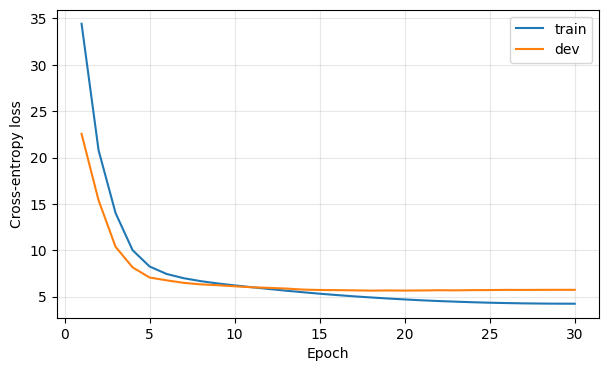

In [20]:
# training curves for the report
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(history["train"]) + 1), history["train"], label="train")
plt.plot(range(1, len(history["dev"]) + 1), history["dev"], label="dev")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()